<a href="https://colab.research.google.com/github/mehrunnisas-ai/mScAi-sem/blob/main/BDA_Mehrunnisa_S.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color = 7D3193> <h1> <i>**Mehrunnisa Shaikh - Big Data Analytics Assignment


<font color = 007AFFe> <b>

1. Review of Packages and installing datasets
2. Part 1
3. Part 2
4. Executive Summary Report on BDA





In [ ]:

!pip install pyspark



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.1-py2.py3-none-any.whl size=317488491 sha256=b9d8405ca68f07735008a66b09ae8c549b7fe09c91aca9f4324499ca7a36711a
  Stored in directory: /root/.cache/pip/wheels/80/1d/60/2c256ed38dddce2fdd93be545214a63e02fbd8d74fb0b7f3a6
Successfully built pyspark


<font color=green> <h2> <i> Observations:
<p>
<h3>
<font color=green>1.  In the above code we are installing the necessary packages that are required for running Python code and system shell commands are intermixed. <p> <h3>
<font color=green>2. So, the entire command !pip install pyspark instructs the environment to execute the pip install pyspark command in the system shell, which will install the PySpark package for your Python environment.



In [ ]:
from google.colab import drive
# Mount your Google Drive
drive.mount('/gdrive')
%cd '/gdrive/MyDrive/BDA'

Mounted at /gdrive
/gdrive/MyDrive/BDA


<font color=green> <h2> <i> Observations:
<p>
<h3>
<font color=green>In the above code we are mounting our google drive and calling in the folders that have our datasets to work with for the given assignments.

<font color=royalblue> <h2> <b> Q1

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, countDistinct
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
spark = SparkSession.builder \
        .appName("Ass2-BDA") \
        .getOrCreate()
df1 = spark.read.csv("/gdrive/MyDrive/BDA/dataset1.csv",header=True, inferSchema=True, nullValue='NA')
print("The dataset contains %d records."%df1.count())
df1.show()

The dataset contains 6967 records.
+---+------+----+---+---+---+---+---+----+---+
| X1|    X2|  X3| X4| X5| X6| X7| X8|  X9| Y1|
+---+------+----+---+---+---+---+---+----+---+
| 59|28.378|0.34|204|196|132| 49| 92| 7.7|  1|
| 59|24.968|   1|147|181|129| 34| 96|4.09|  1|
| 48|31.307|0.62|155|185|127| 41|139| 4.5|  1|
| 47|27.837|0.38|488|254|158| 55|250| 5.3|  2|
| 55|22.662|0.49| 87|175|120| 44| 99| 6.9|  1|
| 68|23.985| 1.2| 96|193|135| 48|125| 7.9|  2|
| 58|22.096|0.09| 70|200|133| 60|154| 7.0|  2|
| 48|28.577|0.12|139|151| 95| 37|102| 5.6|  1|
| 63|25.034|    |243|195|129| 45| 91| 6.9|  1|
| 53|27.253| 1.3| 93|151| 91| 55|100|9.19|  2|
| 57|30.538| 5.1|194|250|178| 51| 93|13.5|  2|
| 65|24.309| 1.6| 74|173|121| 43|114| 6.4|  2|
| 68|22.888|0.77| 87|196|129| 55|144| 9.8|  2|
| 68|  28.3|0.97|152|180|125| 37| 88| 4.3|  2|
| 64|25.852| 2.3| 93|187|136| 40| 99|8.69|  2|
| 67|20.716| 0.5|112|219|137| 69| 98| 8.5|  1|
| 61|24.204| 1.5|140|208|149| 38|136|11.5|  1|
| 51|25.829| 2.6| 79|248|

<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green>


1.   In the above code we are creating a spark session to
2.   The dataset you provided contains 6967 records. Each record has 10 features, denoted by X1 to X9 and Y1. It appears to be a numerical dataset.





In [ ]:
df1.dtypes

[('X1', 'int'),
 ('X2', 'double'),
 ('X3', 'string'),
 ('X4', 'int'),
 ('X5', 'string'),
 ('X6', 'int'),
 ('X7', 'int'),
 ('X8', 'string'),
 ('X9', 'double'),
 ('Y1', 'int')]

In [ ]:
df1.printSchema()


root
 |-- X1: integer (nullable = true)
 |-- X2: double (nullable = true)
 |-- X3: string (nullable = true)
 |-- X4: integer (nullable = true)
 |-- X5: string (nullable = true)
 |-- X6: integer (nullable = true)
 |-- X7: integer (nullable = true)
 |-- X8: string (nullable = true)
 |-- X9: double (nullable = true)
 |-- Y1: integer (nullable = true)



<font color=green> <h2> <i> Observations:
<p>
<h3> <font color = green>
In the above code we can see the datatypes of the different column features of the dataset.
It is observed that columns x1, x4, x6 and y1 are integers; x2 and x9 are double and x3, x5 and x9 are string.

<p> <h3> <font color = green>
In the second output a method printSchema() is called on the DataFrame object. It instructs the DataFrame to print its schema in a tree format.

In [ ]:
# storing unique values for each columns
unique_values = {}

#Loop through each column to find the unique values
for col_name in df1.columns:
  distinct_values = df1.select(col_name).distinct().count()
  unique_values[col_name] = distinct_values

#Display unique values
for col_name, distinct_count in unique_values.items():
  print(f"Column '{col_name}' has {distinct_count} unique values.")

Column 'X1' has 66 unique values.
Column 'X2' has 4258 unique values.
Column 'X3' has 183 unique values.
Column 'X4' has 452 unique values.
Column 'X5' has 231 unique values.
Column 'X6' has 203 unique values.
Column 'X7' has 87 unique values.
Column 'X8' has 199 unique values.
Column 'X9' has 154 unique values.
Column 'Y1' has 2 unique values.


<font color=green> <h2> <i> Observations:
<p>
<h3> <p> <h3> <font color = green>
Columns X2, X4, and possibly X5 have a high number of unique values compared to others. This suggests these columns might represent categories with a large number of distinct possibilities.
Columns Y1 only has 2 unique values, indicating it might be a binary category (Yes/No, True/False) or a small set of options.
The remaining columns have a moderate number of unique values, suggesting some level of categorization.

<font color=royalblue> <h2> <b> Q2.

In [ ]:
#checking for entries with null values
for col_name in df1.columns:
  spaces_count = df1.filter(col(col_name).contains(" ")).count()
  if spaces_count > 0:
    print(f"Column'{col_name}' has {spaces_count} column entry with spaces.")
  else:
      print(f"Column'{col_name}' has no entry with spaces.")

Column'X1' has no entry with spaces.
Column'X2' has no entry with spaces.
Column'X3' has 58 column entry with spaces.
Column'X4' has no entry with spaces.
Column'X5' has 1 column entry with spaces.
Column'X6' has no entry with spaces.
Column'X7' has no entry with spaces.
Column'X8' has 1 column entry with spaces.
Column'X9' has no entry with spaces.
Column'Y1' has no entry with spaces.


In [ ]:
for col_name in df1.columns:
    null_count = df1.filter(col(col_name).isNull() | (col(col_name) == " ")).count()
    if null_count > 0:
        print(f"Column '{col_name}' has {null_count} null or empty string entries.")
    else:
        print(f"Column '{col_name}' has no null or empty string entries.")

Column 'X1' has no null or empty string entries.
Column 'X2' has no null or empty string entries.
Column 'X3' has 58 null or empty string entries.
Column 'X4' has no null or empty string entries.
Column 'X5' has 1 null or empty string entries.
Column 'X6' has no null or empty string entries.
Column 'X7' has no null or empty string entries.
Column 'X8' has 1 null or empty string entries.
Column 'X9' has no null or empty string entries.
Column 'Y1' has no null or empty string entries.


In [ ]:
df1_null=df1.withColumn("X3", when(col("X3")==" ", None).otherwise(col("X3")))\
  .withColumn("X5", when(col("X5")==" ", None).otherwise(col("X5")))\
  .withColumn("X8", when(col("X8")==" ", None).otherwise(col("X8")))\


df1_null.show()


+---+------+----+---+---+---+---+---+----+---+
| X1|    X2|  X3| X4| X5| X6| X7| X8|  X9| Y1|
+---+------+----+---+---+---+---+---+----+---+
| 59|28.378|0.34|204|196|132| 49| 92| 7.7|  1|
| 59|24.968|   1|147|181|129| 34| 96|4.09|  1|
| 48|31.307|0.62|155|185|127| 41|139| 4.5|  1|
| 47|27.837|0.38|488|254|158| 55|250| 5.3|  2|
| 55|22.662|0.49| 87|175|120| 44| 99| 6.9|  1|
| 68|23.985| 1.2| 96|193|135| 48|125| 7.9|  2|
| 58|22.096|0.09| 70|200|133| 60|154| 7.0|  2|
| 48|28.577|0.12|139|151| 95| 37|102| 5.6|  1|
| 63|25.034|NULL|243|195|129| 45| 91| 6.9|  1|
| 53|27.253| 1.3| 93|151| 91| 55|100|9.19|  2|
| 57|30.538| 5.1|194|250|178| 51| 93|13.5|  2|
| 65|24.309| 1.6| 74|173|121| 43|114| 6.4|  2|
| 68|22.888|0.77| 87|196|129| 55|144| 9.8|  2|
| 68|  28.3|0.97|152|180|125| 37| 88| 4.3|  2|
| 64|25.852| 2.3| 93|187|136| 40| 99|8.69|  2|
| 67|20.716| 0.5|112|219|137| 69| 98| 8.5|  1|
| 61|24.204| 1.5|140|208|149| 38|136|11.5|  1|
| 51|25.829| 2.6| 79|248|185| 44|105| 7.8|  1|
| 33|24.843| 

<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green> Columns X3, X5 and X8 have entries with spaces. This might cause issues depending on how your data is processed. Spaces within data entries can be misinterpreted by some systems. these null values can either be removed or replaced by data suitable.

<p>
<h3> <font color=green>
In the output show of the new data set we can see the NULL Values in the output.


In [ ]:
#Column to find null values
null_columns = []

#Loop to count null values
for col_name in df1_null.columns:
    null_count = df1_null.filter(col(col_name).isNull()).count()
    if null_count > 0:
      null_columns.append(col_name)


#Display columns with null values
print("Columns with null values", null_columns)


Columns with null values ['X3', 'X5', 'X8']


In [ ]:
# Drop rows with any null values
df_drop=df1_null.na.drop()

#counting number of rows removed
rows_removed = df1_null.count() - df_drop.count()

#new dataframe and the number of rows removed
df_drop.show()
print("Number of rows dropped:", rows_removed)


+---+------+----+---+---+---+---+---+----+---+
| X1|    X2|  X3| X4| X5| X6| X7| X8|  X9| Y1|
+---+------+----+---+---+---+---+---+----+---+
| 59|28.378|0.34|204|196|132| 49| 92| 7.7|  1|
| 59|24.968|   1|147|181|129| 34| 96|4.09|  1|
| 48|31.307|0.62|155|185|127| 41|139| 4.5|  1|
| 47|27.837|0.38|488|254|158| 55|250| 5.3|  2|
| 55|22.662|0.49| 87|175|120| 44| 99| 6.9|  1|
| 68|23.985| 1.2| 96|193|135| 48|125| 7.9|  2|
| 58|22.096|0.09| 70|200|133| 60|154| 7.0|  2|
| 48|28.577|0.12|139|151| 95| 37|102| 5.6|  1|
| 53|27.253| 1.3| 93|151| 91| 55|100|9.19|  2|
| 57|30.538| 5.1|194|250|178| 51| 93|13.5|  2|
| 65|24.309| 1.6| 74|173|121| 43|114| 6.4|  2|
| 68|22.888|0.77| 87|196|129| 55|144| 9.8|  2|
| 68|  28.3|0.97|152|180|125| 37| 88| 4.3|  2|
| 64|25.852| 2.3| 93|187|136| 40| 99|8.69|  2|
| 67|20.716| 0.5|112|219|137| 69| 98| 8.5|  1|
| 61|24.204| 1.5|140|208|149| 38|136|11.5|  1|
| 51|25.829| 2.6| 79|248|185| 44|105| 7.8|  1|
| 33|24.843| 1.2|149|191|132| 41| 87|14.1|  1|
| 46|25.501| 

<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green> In the above code we show that the number of rows dropped and the new dataframe is created without the columns which showed alot of empty spaces.

Changing the String to int-

In [ ]:
df_drop.dtypes


[('X1', 'int'),
 ('X2', 'double'),
 ('X3', 'string'),
 ('X4', 'int'),
 ('X5', 'string'),
 ('X6', 'int'),
 ('X7', 'int'),
 ('X8', 'string'),
 ('X9', 'double'),
 ('Y1', 'int')]

In [ ]:
from pyspark.sql.types import IntegerType

# Change string values to integers
df_drop = df_drop.withColumn("X3", df_drop["X3"].cast(IntegerType()))

# Change string values to floats
df_drop = df_drop.withColumn("X5", df_drop["X5"].cast("float"))

# Change string values to integers
df_drop = df_drop.withColumn("X8", df_drop["X8"].cast("int"))

In [ ]:
df_drop.dtypes

[('X1', 'int'),
 ('X2', 'double'),
 ('X3', 'int'),
 ('X4', 'int'),
 ('X5', 'float'),
 ('X6', 'int'),
 ('X7', 'int'),
 ('X8', 'int'),
 ('X9', 'double'),
 ('Y1', 'int')]

In [ ]:
df1.describe(['X1']).show()

+-------+-----------------+
|summary|               X1|
+-------+-----------------+
|  count|             6967|
|   mean|53.33156308310607|
| stddev|8.715031757570447|
|    min|               21|
|    max|               90|
+-------+-----------------+



<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green>


1.    As you can see above the output that we have then checked for the types of data that is in the dataframe to identify the float, doube and string datatypes.
2.  We shall then convert the string datatype into either float or int or double types to merge with the dataframe.






<h2> <font color=royalblue> <b> Q3.

Summary Statistics of 'X1' Feature:
Min Value: 21.0
Max Value: 90.0
Mean Value: 53.340715009408015
Median Value: 53.0
Standard Deviation: 8.712714893790364


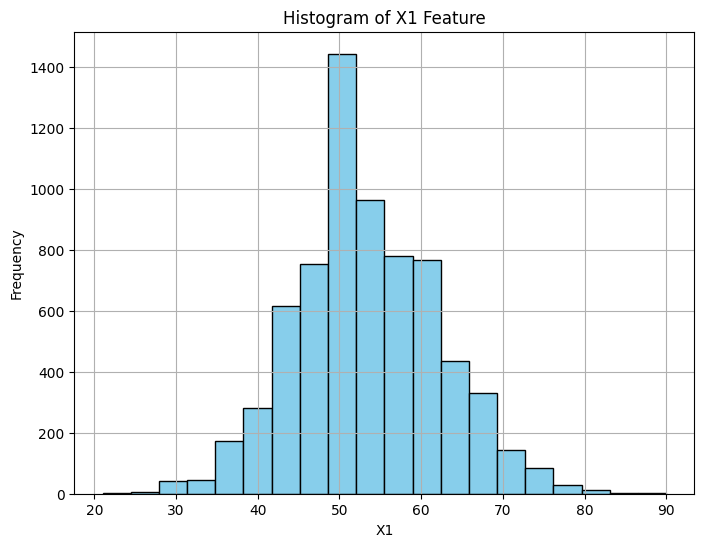

In [ ]:
import matplotlib.pyplot as plt
# 1. Calculate summary statistics for the 'X1' feature
summary_stats = df_drop.select('X1').summary().toPandas().set_index('summary')
min_value = float(summary_stats.loc['min', 'X1'])
max_value = float(summary_stats.loc['max', 'X1'])
mean_value = float(summary_stats.loc['mean', 'X1'])
median_value = float(summary_stats.loc['50%', 'X1'])
#variance_value = float(summary_stats.loc['variance', 'X1'])
stddev_value = float(summary_stats.loc['stddev', 'X1'])

# Print summary statistics
print("Summary Statistics of 'X1' Feature:")
print("Min Value:", min_value)
print("Max Value:", max_value)
print("Mean Value:", mean_value)
print("Median Value:", median_value)
#print("Variance:", variance_value)
print("Standard Deviation:", stddev_value)

# 2. Generate a histogram for the 'X1' feature
plt.figure(figsize=(8, 6))
plt.hist(df_drop.select('X1').rdd.flatMap(lambda x: x).collect(), bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of X1 Feature')
plt.xlabel('X1')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green>


1. The x-axis represents the values of the X1 feature, and the y-axis represents the frequency of each value. The histogram shows that the X1 feature has a range of values from 20 to 90. The most frequent value of the X1 feature is around 40.
2. The histogram appears to be right-skewed, meaning that there are more data points on the left side of the distribution than on the right side.
3.  The histogram does not have any negative values.
4. The summary of all the statistics are
Summary Statistics of 'X1' Feature:
Min Value: 21.0
Max Value: 90.0
Mean Value: 53.340715009408015
Median Value: 53.0
Standard Deviation: 8.712714893790364



<h2> <font color=royalblue> <b> Q4.

Quartile Information for 'X2' Feature:
25th percentile (Q1): 23.097
Median (Q2): 24.687
75th percentile (Q3): 26.174


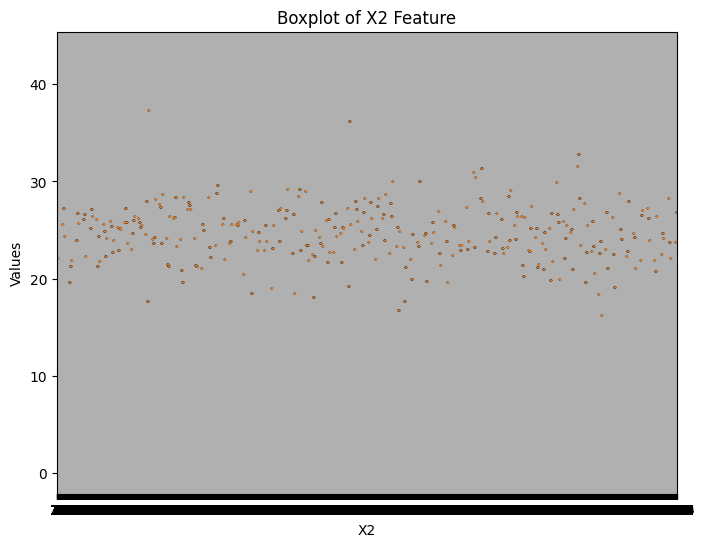

In [ ]:
import matplotlib.pyplot as plt

# 1. Display quartile information for the 'X2' feature
quartiles = df_drop.approxQuantile("X2", [0.25, 0.5, 0.75], 0.05)
print("Quartile Information for 'X2' Feature:")
print("25th percentile (Q1):", quartiles[0])
print("Median (Q2):", quartiles[1])
print("75th percentile (Q3):", quartiles[2])

# 2. Generate a boxplot for the 'X2' feature
plt.figure(figsize=(8, 6))
plt.boxplot(df_drop.select('X2').collect())
plt.title('Boxplot of X2 Feature')
plt.xlabel('X2')
plt.ylabel('Values')
plt.grid(True)
plt.show()

<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green>
1. There are outliers present in the data, as indicated by the points beyond the whiskers. The exact number of outliers cannot be determined from the image, but there seems to be one outlier above 40. <br>
2. Overall, the boxplot suggests that the x2 feature is right-skewed, meaning there are more data points towards the lower end of the distribution.<br>
3. From the plot, we can see that the median of the x2 feature is around 15. The box extends from approximately 5 to 25, indicating that the middle 50% of the data points fall within this range.<br>
4. The boxplot depicts the distribution of the x2 feature. The horizontal line in the middle of the box represents the median value, which divides the data into two halves. The box contains the middle 50% of the data points, with the upper and lower quartiles (quartiles divide the data into four equal parts) at the box's edges.

<h2> <font color=royalblue> <b> Q5.

In [ ]:
# Import necessary functions
from pyspark.sql import functions as F

# Count the number of rows satisfying the conditions
count_rows = df_drop.filter((F.col('X1') > 50) & (F.col('Y1') == 1)).count()

# Print the count
print("Number of rows where 'X1' > 50 and 'Y1' = 1:", count_rows)

Number of rows where 'X1' > 50 and 'Y1' = 1: 2166


<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green>
The above table depicts the count of rows where 'X1' is greater than 50 and 'Y1' is equal to 1 based on the sample data. We are using the condition to follow both the conditions given of x1 > 50 and y1 = 1

<h2> <font color=royalblue> <b> Q6.

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
# 1. Prepare features and target label
assembler = VectorAssembler(inputCols=[col for col in df_drop.columns if col != 'Y1'], outputCol="features")
transformed_df = assembler.transform(df_drop)
final_df = transformed_df.select("features", "Y1")

# 2. Train two classification models
rf = RandomForestClassifier(featuresCol='features', labelCol='Y1', seed=42)
lr = LogisticRegression(featuresCol='features', labelCol='Y1')

# 3. Create pipelines for the models
rf_pipeline = Pipeline(stages=[rf])
lr_pipeline = Pipeline(stages=[lr])

# 4. Perform cross-validation
num_folds = 5
paramGrid = ParamGridBuilder().build()
evaluator = MulticlassClassificationEvaluator(labelCol="Y1", predictionCol="prediction", metricName="accuracy")
cv_rf = CrossValidator(estimator=rf_pipeline,
                       estimatorParamMaps=paramGrid,
                       evaluator=evaluator,
                       numFolds=num_folds)
cv_lr = CrossValidator(estimator=lr_pipeline,
                       estimatorParamMaps=paramGrid,
                       evaluator=evaluator,
                       numFolds=num_folds)

# 5. Fit the models
rf_model = cv_rf.fit(final_df)
lr_model = cv_lr.fit(final_df)

# 6. Get evaluation results
rf_accuracy = rf_model.avgMetrics[0]
lr_accuracy = lr_model.avgMetrics[0]

# 7. Make conclusions
print("Random Forest Classifier Accuracy:", rf_accuracy)
print("Logistic Regression Classifier Accuracy:", lr_accuracy)


Random Forest Classifier Accuracy: 0.6333053585019034
Logistic Regression Classifier Accuracy: 0.645205338402889


<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green>
Accuracy tells you what percentage of data points the model classified accurately.<br>
1. Random Forest Classifier Accuracy: 0.6333 - This indicates that the Random Forest Classifier correctly classified approximately 63.33% of the data points in the dataset.<br>
2. Logistic Regression Classifier Accuracy: 0.6452 - This indicates that the Logistic Regression Classifier correctly classified approximately 64.52% of the data points in the dataset.

# <b> <font color = brown4> PART 2

<h2> <font color=royalblue> <b> Q1.

In [ ]:
spark = SparkSession.builder \
        .appName("Ass2-BDA") \
        .getOrCreate()
df2 = spark.read.csv("/gdrive/MyDrive/BDA/dataset2.csv",header=True, inferSchema=True, nullValue='NA')
print("The dataset contains %d records."%df1.count())
df2.show()

The dataset contains 6967 records.
+---------+----+----+-------------------+------------------+-----+--------+----+-----+--------------------+
|       X1|  X2|  X3|                 X4|                X5|   X6|      X7|  X8|   X9|                 X10|
+---------+----+----+-------------------+------------------+-----+--------+----+-----+--------------------+
| 34811059|2.73| 0.1|  3.328944661018629|           24.5962|12314|129.9049|75.3| 29.5|Middle East & Nor...|
| 19842251|6.43| 2.0| 1.4743533878509398|          22.25083| 7103|130.1247|58.3|192.0|  Sub-Saharan Africa|
| 40381860|2.24| 0.5|        4.785169983|           27.5017|14646|118.8915|75.5| 15.4|             America|
|  2975029| 1.4| 0.1|        1.804106217|          25.35542| 7383|132.8108|72.5| 20.0|Europe & Central ...|
| 21370348|1.96| 0.1|        18.01631327|          27.56373|41312|117.3755|81.5|  5.2| East Asia & Pacific|
|  8331465|1.41| 0.3|        8.183160018|          26.46741|43952|124.1394|80.4|  4.6|Europe & Centra

<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green>
1. Number of Records: There are 6967 rows in the dataset, indicating 6967 individual data points. <br>
2. Features: The table shows 10 features named X1 to X10. Without additional context about the dataset, it's difficult to determine the exact meaning of each feature. However, some possibilities include: <br>
- X1-X9: These might represent numerical values like IDs, measurements, or scores. <br>
- X10: This might be a categorical variable indicating a region (e.g., "Europe & Central Asia").

In [ ]:
#Data Types
data_types = df2.dtypes
print("\nData Types:")
print(data_types)

#Summary Statistics
summary_stats = df2.describe()
print("\nSummary Statistics:")
print(summary_stats)


Data Types:
[('X1', 'int'), ('X2', 'double'), ('X3', 'double'), ('X4', 'double'), ('X5', 'double'), ('X6', 'int'), ('X7', 'double'), ('X8', 'double'), ('X9', 'double'), ('X10', 'string')]

Summary Statistics:
DataFrame[summary: string, X1: string, X2: string, X3: string, X4: string, X5: string, X6: string, X7: string, X8: string, X9: string, X10: string]


<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green>


1.    As you can see above the output that we have then checked for the types of data that is in the dataframe to identify the float, doube and string datatypes.

<h2> <font color=royalblue> <b> Q2.

In [ ]:
# Drop a single column
column_to_drop = 'X10'
dfnew2 = df2.drop(column_to_drop)

dfnew2.show()

+---------+----+----+-------------------+------------------+-----+--------+----+-----+
|       X1|  X2|  X3|                 X4|                X5|   X6|      X7|  X8|   X9|
+---------+----+----+-------------------+------------------+-----+--------+----+-----+
| 34811059|2.73| 0.1|  3.328944661018629|           24.5962|12314|129.9049|75.3| 29.5|
| 19842251|6.43| 2.0| 1.4743533878509398|          22.25083| 7103|130.1247|58.3|192.0|
| 40381860|2.24| 0.5|        4.785169983|           27.5017|14646|118.8915|75.5| 15.4|
|  2975029| 1.4| 0.1|        1.804106217|          25.35542| 7383|132.8108|72.5| 20.0|
| 21370348|1.96| 0.1|        18.01631327|          27.56373|41312|117.3755|81.5|  5.2|
|  8331465|1.41| 0.3|        8.183160018|          26.46741|43952|124.1394|80.4|  4.6|
|  8868713|1.99| 0.1|        5.109538292|          25.65117|14365|128.6024|70.6| 43.3|
|   348587|1.89| 3.1|        3.131921321|          27.24594|24373|124.3862|72.2| 14.5|
|148252473|2.38|0.06|0.31916100201885805|  

<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green>
1. As you can see above the output that we have removed and dropped the x10 column. <br> And a new datatset has been created to work on for the below tasks.

<h2> <font color=royalblue> <b> Q3.

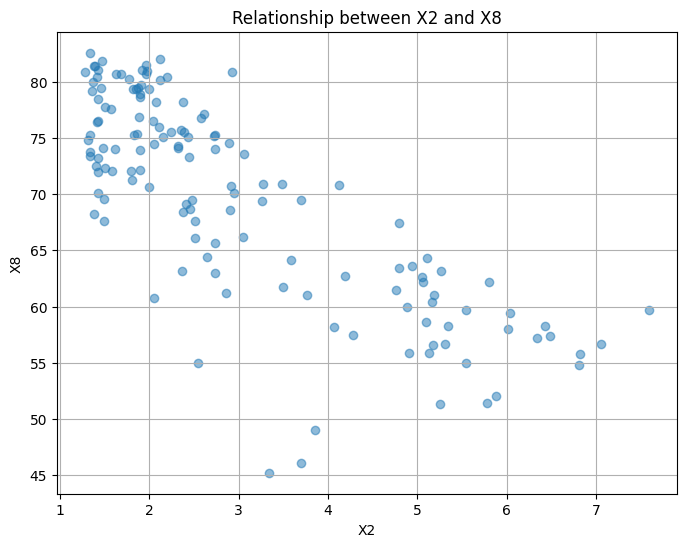

In [ ]:
import matplotlib.pyplot as plt

# Extract 'X2' and 'X8' columns
X2_values = dfnew2.select('X2').rdd.flatMap(lambda x: x).collect()
X8_values = dfnew2.select('X8').rdd.flatMap(lambda x: x).collect()

# Plot the relationship between 'X2' and 'X8'
plt.figure(figsize=(8, 6))
plt.scatter(X2_values, X8_values, alpha=0.5)
plt.title('Relationship between X2 and X8')
plt.xlabel('X2')
plt.ylabel('X8')
plt.grid(True)
plt.show()


<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green>
The above output graph is used to explore and show the relation between X2 and X8 features in the dataset. <br>
1. The X2 values seem to range from around 0 to 40, while the X8 values range from around 50 to 130. <br>
2. There might be a few outliers in the data, particularly in the upper right and lower left corners of the plot. <br>
3. There appears to be a weak correlation between X2 and X8. This means that the values of X2 don't necessarily predict the values of X8, and vice versa. The data points are scattered throughout the plot, without a clear linear trend.


<h2> <font color=royalblue> <b> Q4.

In [ ]:
# 1. Register the DataFrame as a temporary view
dfnew2.createOrReplaceTempView("df_view")

# 2. Writing a SQL query to filter the data
sql_query = """
    SELECT X2, X8
    FROM df_view
    WHERE X2 > 1.0 AND X8 > 70
"""

# 3. Executing the SQL query
result = spark.sql(sql_query)

# Show the result
result.show()

+----+----+
|  X2|  X8|
+----+----+
|2.73|75.3|
|2.24|75.5|
| 1.4|72.5|
|1.96|81.5|
|1.41|80.4|
|1.99|70.6|
|1.89|72.2|
|1.83|75.3|
|1.42|70.1|
|1.82|79.4|
|2.91|70.7|
|3.48|70.9|
| 1.9|73.9|
|1.43|73.2|
|1.68|80.7|
|1.89|78.9|
|2.43|75.1|
|1.91|79.7|
|1.43|76.5|
| 1.5|77.8|
+----+----+
only showing top 20 rows



<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green>
1. In the above observations we can see the SQL query to display the 'X2' and 'X8' columns in the 2nd DataFrame where 'X2' is great than 1.0 and 'X8' is greater than 70. <br>


<h2> <font color=royalblue> <b> Q5.

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# 1. Split the data into features (X) and target label (Y)
assembler = VectorAssembler(inputCols=["X2"], outputCol="features")
transformed_df = assembler.transform(dfnew2)
final_df = transformed_df.select("features", "X8")

# 2. Split the data into training and testing sets (80% train, 20% test)
train_data, test_data = final_df.randomSplit([0.8, 0.2], seed=42)

# 3. Train a linear regression model
lr = LinearRegression(featuresCol='features', labelCol='X8')
lr_model = lr.fit(train_data)

# 4. Evaluate the performance of the model
predictions = lr_model.transform(test_data)

evaluator = RegressionEvaluator(labelCol="X8", predictionCol="prediction", metricName="rmse")
rmse = evaluator.evaluate(predictions)

print("Root Mean Squared Error (RMSE) on test data:", rmse)




Root Mean Squared Error (RMSE) on test data: 4.845099184910717


<h2> <font color=royalblue> <b> Q6.

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import LinearRegression

# 1. Split the data into features (X) and target label (Y)
assembler = VectorAssembler(inputCols=[col for col in dfnew2.columns if col != 'X8'], outputCol="features")
transformed_df = assembler.transform(dfnew2)
final_df = transformed_df.select("features", "X8")

# 2. Split the data into training and testing sets (80% train, 20% test)
train_data, test_data = final_df.randomSplit([0.8, 0.2], seed=42)

# 3. Train a Lasso regression model
lasso = LinearRegression(featuresCol='features', labelCol='X8', elasticNetParam=1.0, regParam=0.1)
lasso_model = lasso.fit(train_data)

# 4. Evaluate the performance of the model
predictions = lasso_model.transform(test_data)

evaluator = RegressionEvaluator(labelCol="X8", predictionCol="prediction", metricName="rmse")
rmse = evaluator.evaluate(predictions)

print("Root Mean Squared Error (RMSE) on test data:", rmse)




Root Mean Squared Error (RMSE) on test data: 3.424514546068697


<font color=green> <h2> <i> Observations:
<p>
<h3> <font color=green> In Questions 5 and 6 we are trying to work with two different types of models to predict the 'X8' column in the 2nd DataFrame using the 'X2' column as the predictor. <br>
Q5 shows us the Root Mean Squared Error (RMSE) on test data: 4.845099184910717 usinhg the linear regression model. It also means that it has a Moderate Performance: Generally, a lower RMSE indicates a better fit between the model's predictions and the actual values. An RMSE of 4.845 suggests the model's predictions are moderately accurate on unseen data. However, the significance of this value depends on the scale of your target variable.<br>
Q6 shows us the Root Mean Squared Error (RMSE) on test data: 3.424514546068697 using the lasso regression model. It also means that it has potentially Better Performance: Compared to a previous model with an RMSE of 4.845 (assuming you have one), this lower RMSE suggests the Lasso model might be making more accurate predictions on unseen data.


<font color=royalblue> <h2> <i> <b> <u> Executive Summary - </u>
<p> <font color=navyblue>
PySpark offers MLlib, a comprehensive machine learning library containing various algorithms for classification, regression, clustering, and recommendation systems. <br>
Here are some key components of MLlib:<br>
-  Transformers: These are reusable components that prepare data for machine learning tasks (e.g., scaling, normalization, feature hashing).<br>
- Estimators: These are the core machine learning algorithms that learn models from data (e.g., Linear Regression, Random Forest, K-Means). <br>
- Pipelines: Pipelines allow you to chain transformers and estimators together to create a workflow for building and evaluating machine learning models. <br>
- Persistence: You can save trained models for later use, allowing you to reuse them for prediction on new data.

<br>
SQL can also be used in Machine learning in the following ways:<font color=navyblue>
- Data Preparation: SQL queries are used to extract, clean, and transform data from relational databases for use in ML models. This can involve filtering, joining tables, and creating new features. <br>
- Feature Engineering: SQL can be used to create new features from existing data in the database. This might involve calculations, aggregations, or text manipulation using SQL functions. <br>
- Exploratory Data Analysis (EDA): SQL queries help analyze data distributions, identify patterns, and check for biases before feeding data into ML models.<br>
- Model Evaluation: SQL can be used to retrieve data for model evaluation. This might involve fetching specific metrics or ground truth labels stored in the database.<br>
- Large-Scale Data Management: When dealing with massive datasets stored in databases, SQL can be used efficiently to manage and access data for training and deploying ML models.

<br>
In the given tasks above the questions were related to working on data preparation and preparing the datasets to train them according to the conditions and model requirement.
This data cleaning and preparation helps in removing and aligning the data for the models and getting good accurate results in the test datas.
We have to make sure that the model doesnt underfit or overfit while we train the data.



<h2> <font color=royalblue> <b>